In [2]:
# Importamos librerias
from scipy.special import legendre
import numpy as np
import matplotlib.pyplot as plt
import time
from fenics import *
from dolfin_adjoint import *
from moola import *
import pandas as pd
import moola as moola

In [3]:
n=39
lim_inf=-1
lim_sup=1
mesh = IntervalMesh(n,lim_inf,lim_sup)

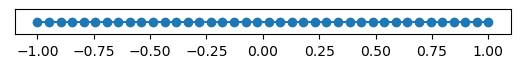

In [4]:
plot(mesh)

In [5]:
V = FunctionSpace(mesh, "CG", 1)
W = FunctionSpace(mesh, "DG", 0)

In [6]:
f = interpolate(Expression("x[0]", name='Control', degree=1), W)

In [7]:
u = Function(V, name='State')
v = TestFunction(V)


In [8]:
F = (inner(grad(u), grad(v)) - f * v) * dx
bc = DirichletBC(V, 0.0, "on_boundary")
solve(F == 0, u, bc)


No Jacobian form specified for nonlinear variational problem.
Differentiating residual form F to obtain Jacobian J = F'.
Solving nonlinear variational problem.
  Newton iteration 0: r (abs) = 1.778e-01 (tol = 1.000e-10) r (rel) = 1.000e+00 (tol = 1.000e-09)
  Newton iteration 1: r (abs) = 1.460e-15 (tol = 1.000e-10) r (rel) = 8.211e-15 (tol = 1.000e-09)
  Newton solver finished in 1 iterations and 1 linear solver iterations.


In [9]:
u_sol=pd.read_csv('u_solution.csv',header=None)
u_soluc=np.zeros(u_sol.shape[0])

In [10]:
for i in range(u_sol.shape[0]):
    u_soluc[i]=u_sol.iloc[i]

In [11]:
len(u_soluc)

40

In [32]:
len(u.vector()[:])

40

In [12]:
# Asignamos la solucion que teníamos
u.vector()[:]=u_soluc

In [28]:
u.vector()[30]

0.1748332719383827

In [30]:
mesh.coordinates()[:]=mesh.coordinates()[::-1]

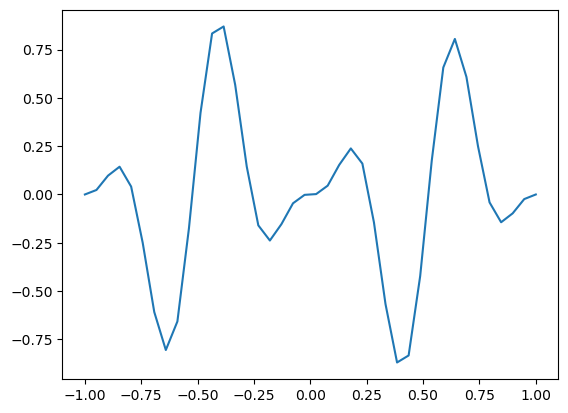

In [32]:
plot(u)

In [33]:
x = SpatialCoordinate(mesh)
d=Expression("pow(sin(pi*x[0]),2) * sin(12*x[0]) ",degree=3)

In [34]:
alpha = Constant(1e-6)
J = assemble((0.5 * inner(u - d, u - d)) * dx + alpha / 2 * f ** 2 * dx)
control = Control(f)

In [35]:
rf = ReducedFunctional(J, control)

In [36]:
problem = MoolaOptimizationProblem(rf)
f_moola = moola.DolfinPrimalVector(f)
solver = moola.NewtonCG(problem, f_moola, options={'gtol': 1e-9,
                                                   'maxiter': 20,
                                                   'display': 3,
                                                   'ncg_hesstol': 0})

In [37]:
sol = solver.solve()
f_opt = sol['control'].data

Newton CG method.
------------------------------
Line search:		 strong_wolfe
Maximum iterations:	 20

No Jacobian form specified for nonlinear variational problem.
Differentiating residual form F to obtain Jacobian J = F'.
Solving nonlinear variational problem.
  Newton iteration 0: r (abs) = 1.778e-01 (tol = 1.000e-10) r (rel) = 1.000e+00 (tol = 1.000e-09)
  Newton iteration 1: r (abs) = 1.460e-15 (tol = 1.000e-10) r (rel) = 8.211e-15 (tol = 1.000e-09)
  Newton solver finished in 1 iterations and 1 linear solver iterations.
iteration = 0:	objective = 0.18951823433799247:	grad_norm = 0.011833896648186161:
TEST: 0.00014004110987995164 1.6572320208166296e-06
cg_iter = 0	curve = 8.964903997608719e-07	hesstol = 0
TEST: 7.647557185104247e-05 1.6572320208166296e-06
cg_iter = 1	curve = 6.152960019628586e-08	hesstol = 0
TEST: 1.0734199284668946e-05 1.6572320208166296e-06
cg_iter = 2	curve = 6.230460174235641e-10	hesstol = 0
TEST: 3.4736023235540554e-06 1.6572320208166296e-06
cg_iter = 3	curve 

In [38]:
# Define the expressions of the analytical solution
dt = 0.0000001
a = np.pi
b = 12
c = 12
alpha = 1
f_analytic=Expression("((c-pow(b,3)*alpha)*pow(sin(a*x[0]),2) + 6*pow(a,2)*b*alpha*cos(2*a*x[0]))*cos(b*x[0] + c*dt) - a*alpha*(4*pow(a,2) + 3*pow(b,2))*sin(2*a*x[0])*sin(b*x[0]+c*dt)",a=a,b=b,c=c,alpha=alpha,dt=dt,degree=3)
u_analytic = Expression("pow(sin(pi*x[0]),2) * sin(12*x[0])+ c*dt ", c=c, dt=dt,degree=3)

In [39]:
f.assign(f_opt)
solve(F == 0, u, bc)
control_error = errornorm(f_analytic, f_opt)
state_error = errornorm(u_analytic, u)
print("h(min):           %e." % mesh.hmin())
print("Error in state:   %e." % state_error)
print("Error in control: %e." % control_error)

No Jacobian form specified for nonlinear variational problem.
Differentiating residual form F to obtain Jacobian J = F'.
Solving nonlinear variational problem.
  Newton iteration 0: r (abs) = 4.673e+01 (tol = 1.000e-10) r (rel) = 1.000e+00 (tol = 1.000e-09)
  Newton iteration 1: r (abs) = 3.357e-14 (tol = 1.000e-10) r (rel) = 7.183e-16 (tol = 1.000e-09)
  Newton solver finished in 1 iterations and 1 linear solver iterations.
h(min):           5.128205e-02.
Error in state:   3.490884e-02.
Error in control: 1.751487e+03.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
